Mounted at /content/drive


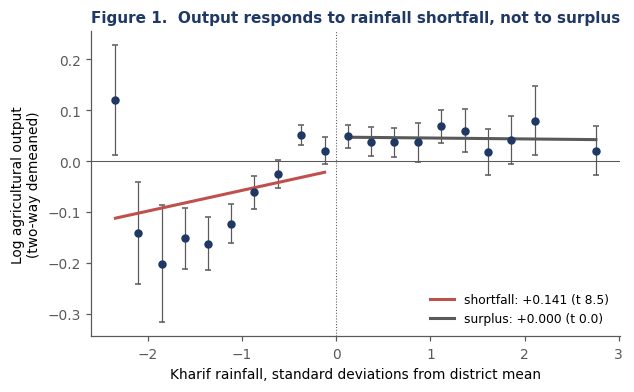

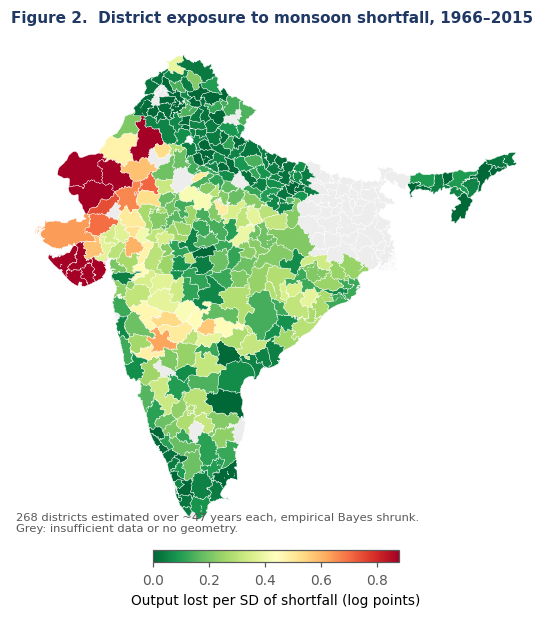

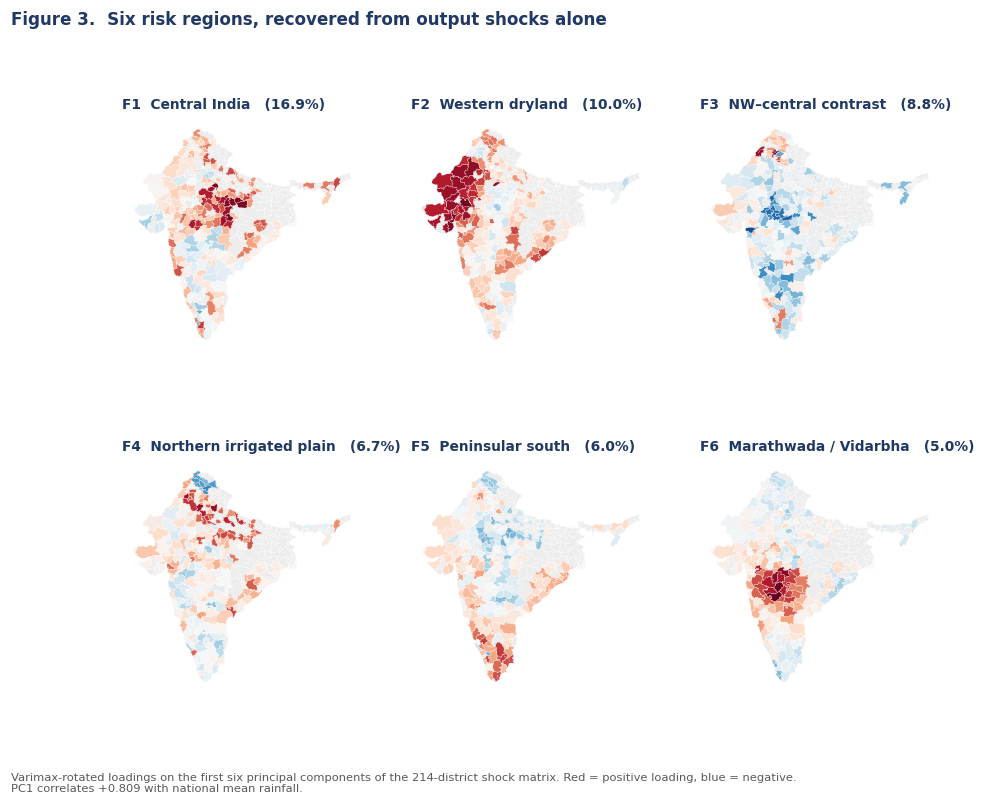

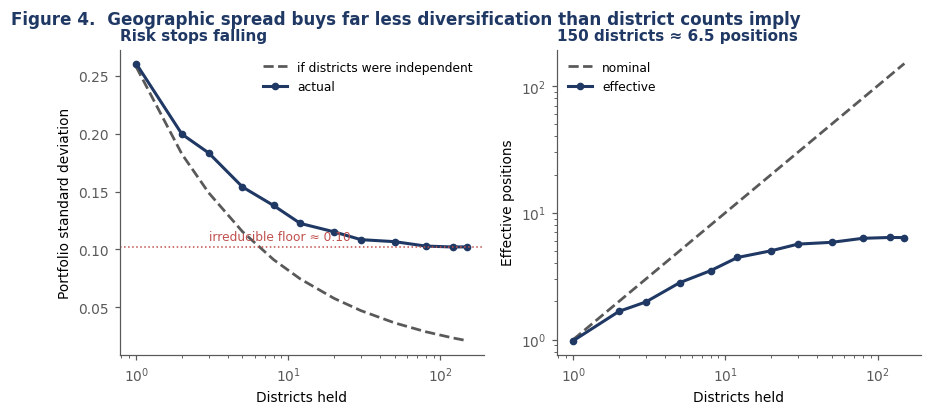

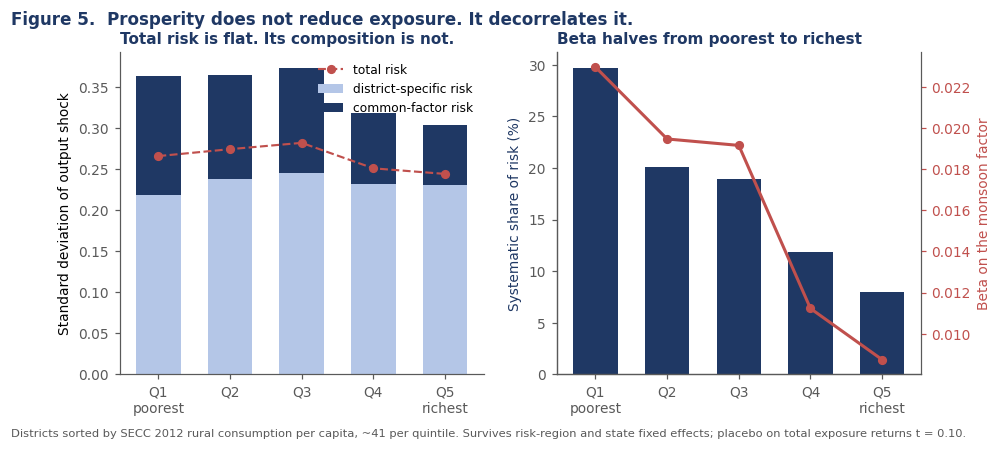

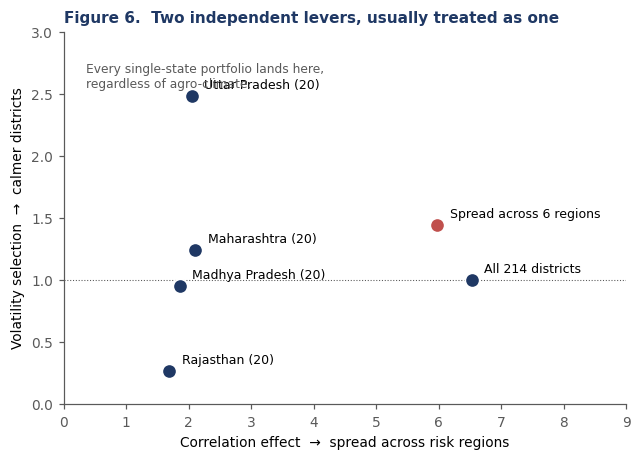

saved to /content/drive/My Drive/Data/Elevar/figures


In [ ]:
# 06_figures — publication figures
import pandas as pd, numpy as np, json, matplotlib as mpl, matplotlib.pyplot as plt
import statsmodels.api as sm, geopandas as gpd
from matplotlib.gridspec import GridSpec
from google.colab import drive; drive.mount('/content/drive')

BASE = '/content/drive/My Drive/Data/Elevar'
FIG  = f'{BASE}/figures'; import os; os.makedirs(FIG, exist_ok=True)

NAVY, ACC, GREY = '#1F3864', '#C0504D', '#595959'
mpl.rcParams.update({'font.family':'DejaVu Sans','font.size':9,'axes.edgecolor':GREY,
    'axes.labelcolor':'black','axes.titlesize':10,'axes.titleweight':'bold','axes.titlecolor':NAVY,
    'xtick.color':GREY,'ytick.color':GREY,'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight','legend.frameon':False})

W   = pd.read_parquet(f'{BASE}/shock_matrix.parquet')
L   = pd.read_parquet(f'{BASE}/factor_loadings.parquet').set_index('Dist Code')
S   = pd.read_parquet(f'{BASE}/systematic_share.parquet').set_index('Dist Code')
A   = pd.read_parquet(f'{BASE}/axisA_sensitivity.parquet').set_index('Dist Code')
crops = pd.read_parquet(f'{BASE}/crops_clean.parquet')
r     = pd.read_parquet(f'{BASE}/rainfall_shock.parquet'); r = r[r['Dist Code']<800]
geo = gpd.read_file(f'{BASE}/icrisat_districts.geojson').set_index('Dist Code')

# ---------------- FIG 1: the asymmetry ----------------
P = crops.merge(r, on=['Dist Code','Year']).dropna(subset=['ln_ag_output','rain_z'])
P['res'] = P.ln_ag_output - P.groupby('Dist Code').ln_ag_output.transform('mean') \
           - P.groupby('Year').ln_ag_output.transform('mean') + P.ln_ag_output.mean()
P['bin'] = pd.cut(P.rain_z.clip(-2.5,2.5), np.arange(-2.5,2.75,.25))
g = P.groupby('bin', observed=True).agg(x=('rain_z','mean'), y=('res','mean'),
                                        se=('res', lambda s: s.std()/np.sqrt(len(s)))).dropna()
fig, ax = plt.subplots(figsize=(6.2,3.6))
ax.axhline(0, lw=.7, c=GREY, zorder=0); ax.axvline(0, lw=.7, c=GREY, ls=':', zorder=0)
ax.errorbar(g.x, g.y, yerr=1.96*g.se, fmt='o', ms=4.5, c=NAVY, ecolor=GREY, elinewidth=.8, capsize=2)
neg, pos = g[g.x<0], g[g.x>0]
for sub, c, lab in [(neg, ACC, 'shortfall: +0.141 (t 8.5)'), (pos, GREY, 'surplus: +0.000 (t 0.0)')]:
    b = np.polyfit(sub.x, sub.y, 1); xs = np.linspace(sub.x.min(), sub.x.max(), 20)
    ax.plot(xs, np.polyval(b, xs), c=c, lw=2, label=lab)
ax.set_xlabel('Kharif rainfall, standard deviations from district mean')
ax.set_ylabel('Log agricultural output\n(two-way demeaned)')
ax.set_title('Figure 1.  Output responds to rainfall shortfall, not to surplus', loc='left')
ax.legend(loc='lower right', fontsize=8)
plt.savefig(f'{FIG}/fig1_asymmetry.png'); plt.show()

# ---------------- FIG 2: exposure choropleth ----------------
G = geo.join(A[['exposure']]).join(L[['region']])
fig, ax = plt.subplots(figsize=(6.4,7.2))
G[G.exposure.isna()].plot(ax=ax, color='#EDEDED', edgecolor='white', lw=.25)
G.dropna(subset=['exposure']).plot(ax=ax, column='exposure', cmap='RdYlGn_r', scheme=None,
    vmin=0, vmax=G.exposure.quantile(.97), edgecolor='white', lw=.25,
    legend=True, legend_kwds={'shrink':.45,'label':'Output lost per SD of shortfall (log points)',
                              'orientation':'horizontal','pad':0.01})
ax.set_axis_off()
ax.set_title('Figure 2.  District exposure to monsoon shortfall, 1966–2015', loc='left')
ax.text(.01,.02,'268 districts estimated over ~47 years each, empirical Bayes shrunk.\nGrey: insufficient data or no geometry.',
        transform=ax.transAxes, fontsize=7.5, color=GREY, va='bottom')
plt.savefig(f'{FIG}/fig2_exposure_map.png'); plt.show()

# ---------------- FIG 3: six risk regions ----------------
FN = {'F1':'F1  Central India','F2':'F2  Western dryland','F3':'F3  NW–central contrast',
      'F4':'F4  Northern irrigated plain','F5':'F5  Peninsular south','F6':'F6  Marathwada / Vidarbha'}
VAR = {'F1':'16.9%','F2':'10.0%','F3':'8.8%','F4':'6.7%','F5':'6.0%','F6':'5.0%'}
fig, axes = plt.subplots(2, 3, figsize=(9.6,7.4))
for k,(f,ax) in enumerate(zip(['F1','F2','F3','F4','F5','F6'], axes.ravel())):
    Gf = geo.join(L[[f]])
    Gf[Gf[f].isna()].plot(ax=ax, color='#EDEDED', edgecolor='white', lw=.15)
    Gf.dropna(subset=[f]).plot(ax=ax, column=f, cmap='RdBu_r', vmin=-.9, vmax=.9,
                               edgecolor='white', lw=.15)
    ax.set_axis_off(); ax.set_title(f'{FN[f]}   ({VAR[f]})', loc='left', fontsize=9)
fig.suptitle('Figure 3.  Six risk regions, recovered from output shocks alone',
             x=.02, ha='left', color=NAVY, fontweight='bold', fontsize=11, y=.98)
fig.text(.02,.02,'Varimax-rotated loadings on the first six principal components of the 214-district shock matrix. '
                 'Red = positive loading, blue = negative.\nPC1 correlates +0.809 with national mean rainfall.',
         fontsize=7.5, color=GREY)
plt.savefig(f'{FIG}/fig3_regions.png'); plt.show()

# ---------------- FIG 4: effective diversification ----------------
sd1 = W.std().mean(); rng = np.random.default_rng(7); cols = list(W.columns)
ks = [1,2,3,5,8,12,20,30,50,80,120,150]
act, ind = [], []
for k in ks:
    act.append(np.mean([W[rng.choice(cols,k,replace=False)].mean(axis=1).std() for _ in range(300)]))
    ind.append(sd1/np.sqrt(k))
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(9.4,3.6))
ax1.plot(ks, ind, '--', c=GREY, lw=1.8, label='if districts were independent')
ax1.plot(ks, act, '-o', c=NAVY, lw=2, ms=4, label='actual')
ax1.axhline(act[-1], c=ACC, lw=1, ls=':');
ax1.text(3, act[-1]*1.06, f'irreducible floor ≈ {act[-1]:.2f}', color=ACC, fontsize=8)
ax1.set_xscale('log'); ax1.set_xlabel('Districts held'); ax1.set_ylabel('Portfolio standard deviation')
ax1.set_title('Risk stops falling', loc='left'); ax1.legend(fontsize=8)
keff = [(sd1/a)**2 for a in act]
ax2.plot(ks, ks, '--', c=GREY, lw=1.8, label='nominal')
ax2.plot(ks, keff, '-o', c=NAVY, lw=2, ms=4, label='effective')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Districts held'); ax2.set_ylabel('Effective positions')
ax2.set_title('150 districts ≈ 6.5 positions', loc='left'); ax2.legend(fontsize=8)
fig.suptitle('Figure 4.  Geographic spread buys far less diversification than district counts imply',
             x=.02, ha='left', color=NAVY, fontweight='bold', fontsize=11)
plt.savefig(f'{FIG}/fig4_diversification.png'); plt.show()

# ---------------- FIG 5: the central result ----------------
D = S.dropna(subset=['r2_sys','secc_cons_pc_rural']).copy()
D['sys_sd'] = np.sqrt((D.tot_sd**2 - D.idio_sd**2).clip(lower=0))
D['q'] = pd.qcut(D.secc_cons_pc_rural, 5, labels=['Q1\npoorest','Q2','Q3','Q4','Q5\nrichest'])
Q = D.groupby('q', observed=True)[['sys_sd','idio_sd','tot_sd','r2_sys','beta']].mean()
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(9.4,3.8))
x = np.arange(5)
ax1.bar(x, Q.idio_sd, .62, label='district-specific risk', color='#B4C6E7')
ax1.bar(x, Q.sys_sd, .62, bottom=Q.idio_sd, label='common-factor risk', color=NAVY)
ax1.plot(x, Q.tot_sd, 'o--', c=ACC, ms=5, lw=1.4, label='total risk')
ax1.set_xticks(x); ax1.set_xticklabels(Q.index); ax1.set_ylabel('Standard deviation of output shock')
ax1.set_title('Total risk is flat. Its composition is not.', loc='left'); ax1.legend(fontsize=8, loc='upper right')
ax2b = ax2.twinx()
ax2.bar(x, Q.r2_sys*100, .62, color=NAVY); ax2.set_xticks(x); ax2.set_xticklabels(Q.index)
ax2.set_ylabel('Systematic share of risk (%)', color=NAVY)
ax2b.plot(x, Q.beta, 'o-', c=ACC, ms=5, lw=2); ax2b.set_ylabel('Beta on the monsoon factor', color=ACC)
ax2b.spines['right'].set_visible(True); ax2b.tick_params(colors=ACC)
ax2.set_title('Beta halves from poorest to richest', loc='left')
fig.suptitle('Figure 5.  Prosperity does not reduce exposure. It decorrelates it.',
             x=.02, ha='left', color=NAVY, fontweight='bold', fontsize=11)
fig.text(.02,-.04,'Districts sorted by SECC 2012 rural consumption per capita, ~41 per quintile. '
                  'Survives risk-region and state fixed effects; placebo on total exposure returns t = 0.10.',
         fontsize=7.5, color=GREY)
plt.savefig(f'{FIG}/fig5_decorrelation.png'); plt.show()

# ---------------- FIG 6: two levers ----------------
def dec(cols):
    cols=[c for c in cols if c in W.columns]; w=np.ones(len(cols))/len(cols)
    psd=(W[cols]*w).sum(axis=1).std(); isd=float((W[cols].std().values*w).sum())
    return (isd/psd)**2, (sd1/isd)**2
pts={}
for s in ['Rajasthan','Madhya Pradesh','Maharashtra','Uttar Pradesh']:
    pts[s+' (20)'] = dec(L[L['State Name']==s].index.tolist()[:20])
regions=L.region.unique(); sp=[]
for i in range(20):
    p=[c for c in L[L.region==regions[i%6]].index if c in W.columns and c not in sp]
    if p: sp.append(rng.choice(p))
pts['Spread across 6 regions']=dec(sp)
pts['All 214 districts']=dec(list(W.columns))
fig, ax = plt.subplots(figsize=(6.6,4.4))
for lab,(kp,vs) in pts.items():
    c = ACC if 'Spread' in lab else NAVY
    ax.scatter(kp, vs, s=90, c=c, zorder=3, edgecolor='white', lw=1.2)
    ax.annotate(lab, (kp,vs), textcoords='offset points', xytext=(8,5), fontsize=8.2)
ax.axhline(1, lw=.7, c=GREY, ls=':'); ax.set_xlim(0,9); ax.set_ylim(0,3)
ax.set_xlabel('Correlation effect  →  spread across risk regions')
ax.set_ylabel('Volatility selection  →  calmer districts')
ax.set_title('Figure 6.  Two independent levers, usually treated as one', loc='left')
ax.text(.35,2.55,'Every single-state portfolio lands here,\nregardless of agro-climate.',
        fontsize=8, color=GREY)
plt.savefig(f'{FIG}/fig6_two_levers.png'); plt.show()

print('saved to', FIG)

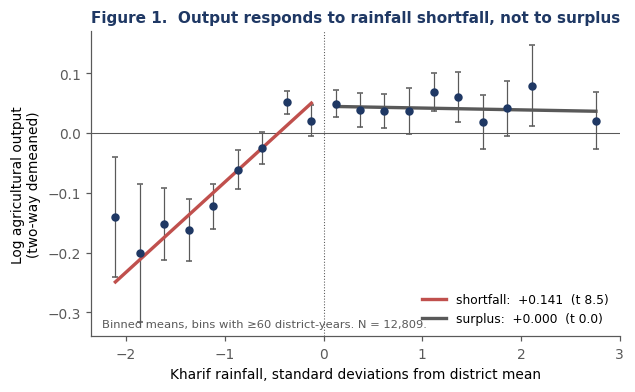

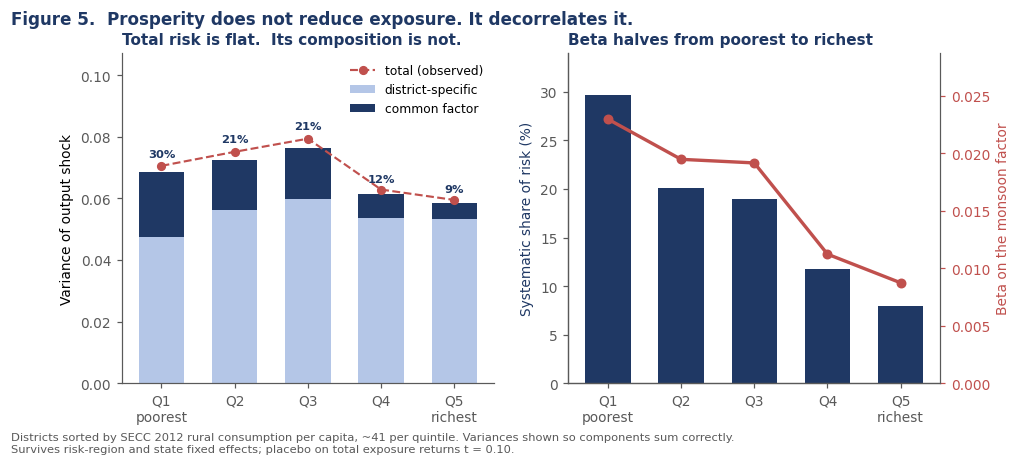

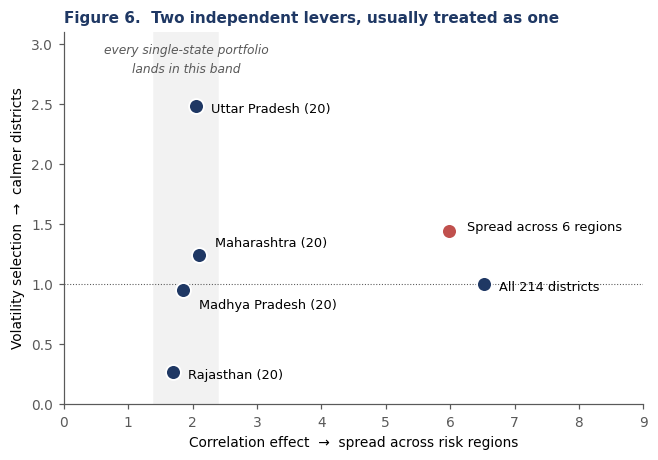

In [ ]:
# 06_figures — CELL 2: corrected figures 1, 5, 6
import numpy as np, pandas as pd, matplotlib.pyplot as plt
FIG = f'{BASE}/figures'

# ---------------- FIG 1 (min bin count) ----------------
g = (P.groupby('bin', observed=True)
       .agg(x=('rain_z','mean'), y=('res','mean'), n=('res','size'),
            se=('res', lambda s: s.std()/np.sqrt(len(s)))).dropna())
g = g[g.n >= 60]
fig, ax = plt.subplots(figsize=(6.2,3.6))
ax.axhline(0, lw=.7, c=GREY, zorder=0); ax.axvline(0, lw=.7, c=GREY, ls=':', zorder=0)
ax.errorbar(g.x, g.y, yerr=1.96*g.se, fmt='o', ms=4.5, c=NAVY, ecolor=GREY, elinewidth=.8, capsize=2)
for sub, c, lab in [(g[g.x<0], ACC, 'shortfall:  +0.141  (t 8.5)'),
                    (g[g.x>0], GREY, 'surplus:  +0.000  (t 0.0)')]:
    b = np.polyfit(sub.x, sub.y, 1, w=sub.n); xs = np.linspace(sub.x.min(), sub.x.max(), 20)
    ax.plot(xs, np.polyval(b, xs), c=c, lw=2.2, label=lab)
ax.set_xlabel('Kharif rainfall, standard deviations from district mean')
ax.set_ylabel('Log agricultural output\n(two-way demeaned)')
ax.set_title('Figure 1.  Output responds to rainfall shortfall, not to surplus', loc='left')
ax.legend(loc='lower right', fontsize=8)
ax.text(.02,.03,f'Binned means, bins with ≥60 district-years. N = {len(P):,}.',
        transform=ax.transAxes, fontsize=7.5, color=GREY)
plt.savefig(f'{FIG}/fig1_asymmetry.png'); plt.show()

# ---------------- FIG 5 (variance decomposition) ----------------
Q = D.groupby('q', observed=True)[['sys_sd','idio_sd','tot_sd','r2_sys','beta']].mean()
Qv = Q.assign(sys_v=Q.sys_sd**2, idio_v=Q.idio_sd**2, tot_v=Q.tot_sd**2)
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(9.6,3.9))
x = np.arange(5)
ax1.bar(x, Qv.idio_v, .62, label='district-specific', color='#B4C6E7')
ax1.bar(x, Qv.sys_v, .62, bottom=Qv.idio_v, label='common factor', color=NAVY)
ax1.plot(x, Qv.tot_v, 'o--', c=ACC, ms=5, lw=1.4, label='total (observed)')
ax1.set_xticks(x); ax1.set_xticklabels(Q.index)
ax1.set_ylabel('Variance of output shock')
ax1.set_ylim(0, Qv.tot_v.max()*1.35)
ax1.set_title('Total risk is flat.  Its composition is not.', loc='left')
ax1.legend(fontsize=8, loc='upper right', ncol=1)
for i,(a,b) in enumerate(zip(Qv.sys_v, Qv.tot_v)):
    ax1.text(i, b*1.04, f'{a/b:.0%}', ha='center', fontsize=7.5, color=NAVY, fontweight='bold')
ax2b = ax2.twinx()
ax2.bar(x, Q.r2_sys*100, .62, color=NAVY)
ax2.set_xticks(x); ax2.set_xticklabels(Q.index)
ax2.set_ylabel('Systematic share of risk (%)', color=NAVY); ax2.set_ylim(0,34)
ax2b.plot(x, Q.beta, 'o-', c=ACC, ms=5.5, lw=2.2)
ax2b.set_ylabel('Beta on the monsoon factor', color=ACC); ax2b.set_ylim(0, Q.beta.max()*1.25)
ax2b.spines['right'].set_visible(True); ax2b.tick_params(colors=ACC)
ax2.set_title('Beta halves from poorest to richest', loc='left')
fig.suptitle('Figure 5.  Prosperity does not reduce exposure. It decorrelates it.',
             x=.02, ha='left', color=NAVY, fontweight='bold', fontsize=11)
fig.text(.02,-.05,'Districts sorted by SECC 2012 rural consumption per capita, ~41 per quintile. Variances shown so components sum correctly.\n'
                  'Survives risk-region and state fixed effects; placebo on total exposure returns t = 0.10.',
         fontsize=7.5, color=GREY)
plt.savefig(f'{FIG}/fig5_decorrelation.png'); plt.show()

# ---------------- FIG 6 (label placement) ----------------
OFF = {'Rajasthan (20)':(10,-4),'Madhya Pradesh (20)':(10,-12),'Maharashtra (20)':(10,6),
       'Uttar Pradesh (20)':(10,-4),'Spread across 6 regions':(12,0),'All 214 districts':(10,-4)}
fig, ax = plt.subplots(figsize=(6.8,4.4))
ax.axvspan(1.4, 2.4, color='#F2F2F2', zorder=0)
for lab,(kp,vs) in pts.items():
    c = ACC if 'Spread' in lab else NAVY
    ax.scatter(kp, vs, s=95, c=c, zorder=3, edgecolor='white', lw=1.2)
    ax.annotate(lab, (kp,vs), textcoords='offset points', xytext=OFF.get(lab,(9,5)), fontsize=8.4)
ax.axhline(1, lw=.7, c=GREY, ls=':')
ax.set_xlim(0,9); ax.set_ylim(0,3.1)
ax.text(1.9, 2.92, 'every single-state portfolio', ha='center', fontsize=8, color=GREY, style='italic')
ax.text(1.9, 2.76, 'lands in this band', ha='center', fontsize=8, color=GREY, style='italic')
ax.set_xlabel('Correlation effect  →  spread across risk regions')
ax.set_ylabel('Volatility selection  →  calmer districts')
ax.set_title('Figure 6.  Two independent levers, usually treated as one', loc='left')
plt.savefig(f'{FIG}/fig6_two_levers.png'); plt.show()